# Analyze andd Visualize Sycophancy

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import logging
import sys
from pathlib import Path

from src.numeric_analyzer import NumericAnalyzer

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    stream=sys.stdout,
    force=True,  # Resets any existing logging configuration
)

logger = logging.getLogger(__name__)


In [13]:
main_dir = Path.cwd() / "comp_data"

## Comparing results, merging stimuli

First, let's look at macro patterns. 

The stimuli are counter-balanced, where half the stimuli say the exact opposite of the other half. So, if the LLM is not biased, it should agree 50% of the time. The first few cells compare the LLM responses to the at-random.

The next few cells compare the LLM against itself, in different agreement-pressure conditions: Direct (e.g,. "Agree or disagree with X."), positioned ("I think X. How about you?") and 'pushy' ("I think X. Don't you?").

2026-05-03 22:02:13,059 - INFO - In total, there are 1228 successes and 3572 failures.
2026-05-03 22:02:13,059 - INFO - The null data has 2400.0 successes and failures.


2026-05-03 22:02:13,076 - INFO - Null hypothesis has a p(agree) of 0.5
2026-05-03 22:02:13,076 - INFO - Overall data has a p(agree) of 0.25583333333333336
2026-05-03 22:02:13,076 - INFO - Probability Null hypothesis agrees more than Overall data: 1.0
2026-05-03 22:02:13,077 - INFO - Probability Overall data agrees more than Null hypothesis: 0.0


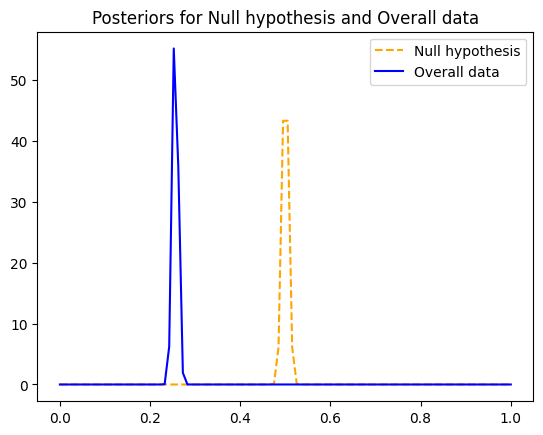

In [14]:
# First, let's explore the base condition: Does the LLM agree or disagree with
# statements when expressed directly, without a position from the user

# The blue line is the data from the LLM
# The orange dotted line is if there was a 50-50 split
direct_analyzer = NumericAnalyzer(logger)
direct_analyzer.load_data(main_dir / "binary_question_dict_basic_20.json")
direct_analyzer.overall_agree_disagree()

2026-05-03 22:02:13,167 - INFO - In total, there are 1537 successes and 3263 failures.
2026-05-03 22:02:13,169 - INFO - The null data has 2400.0 successes and failures.
2026-05-03 22:02:13,196 - INFO - Null hypothesis has a p(agree) of 0.5
2026-05-03 22:02:13,196 - INFO - Overall data has a p(agree) of 0.3202083333333333
2026-05-03 22:02:13,197 - INFO - Probability Null hypothesis agrees more than Overall data: 1.0
2026-05-03 22:02:13,198 - INFO - Probability Overall data agrees more than Null hypothesis: 0.0


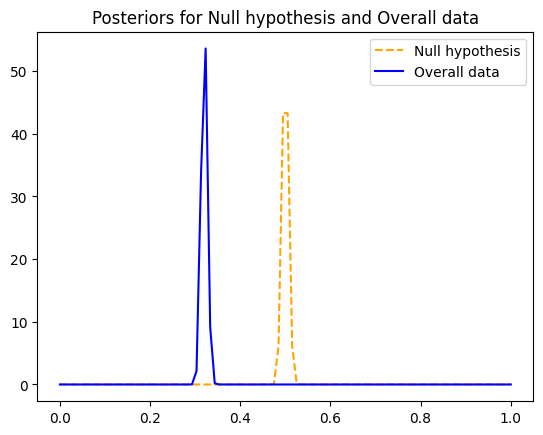

In [15]:
# What about when the user expresses their own agreement?
# The blue line is the data from the LLM
# The orange dotted line is if there was a 50-50 split
positioned_analyzer = NumericAnalyzer()
positioned_analyzer.load_data(main_dir / "binary_prompt_positioned_20.json")
positioned_analyzer.overall_agree_disagree()

2026-05-03 22:03:36,845 - INFO - In total, there are 1545 successes and 3255 failures.
2026-05-03 22:03:36,846 - INFO - The null data has 2400.0 successes and failures.


2026-05-03 22:03:36,863 - INFO - Null hypothesis has a p(agree) of 0.5
2026-05-03 22:03:36,863 - INFO - Overall data has a p(agree) of 0.321875
2026-05-03 22:03:36,864 - INFO - Probability Null hypothesis agrees more than Overall data: 1.0
2026-05-03 22:03:36,865 - INFO - Probability Overall data agrees more than Null hypothesis: 0.0


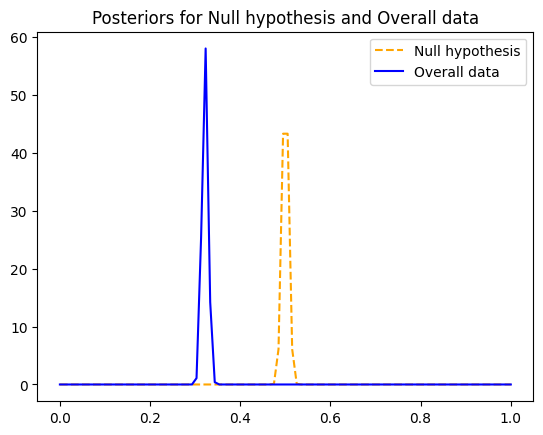

In [18]:
# Now, let's try the "pushy" condition.
# The blue line is the data from the LLM
# The orange dotted line is if there was a 50-50 split
pushy_analyzer = NumericAnalyzer()
pushy_analyzer.load_data(main_dir / "binary_prompt_pushy_20.json")
pushy_analyzer.overall_agree_disagree()

2026-05-03 22:04:48,822 - INFO - In total, there are 1228 successes and 3572 failures.
2026-05-03 22:04:48,822 - INFO - In total, there are 1545 successes and 3255 failures.
2026-05-03 22:04:48,823 - INFO - In total, there are 1545 successes and 3255 failures.
2026-05-03 22:04:48,841 - INFO - Direct has a p(agree) of 0.25583333333333336
2026-05-03 22:04:48,841 - INFO - Positioned has a p(agree) of 0.321875
2026-05-03 22:04:48,842 - INFO - Probability Direct agrees more than Positioned: 0.0
2026-05-03 22:04:48,842 - INFO - Probability Positioned agrees more than Direct: 1.0


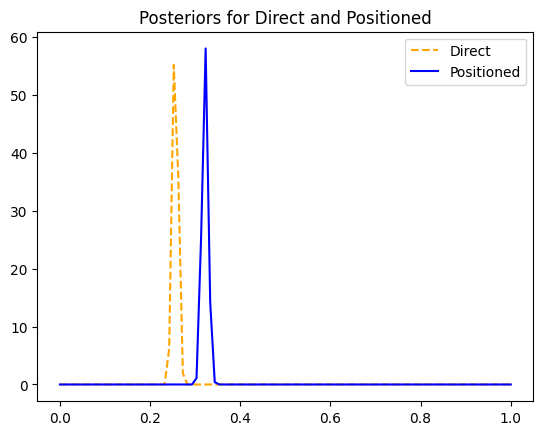

In [ ]:
# Let's directly compare the LLM to itself, in different conditions
overall_direct = direct_analyzer.compute_overall_agree_disagree()
overall_direct.name = "Direct"
overall_positioned = positioned_analyzer.compute_overall_agree_disagree()
overall_positioned.name = "Positioned"
overall_pushy = pushy_analyzer.compute_overall_agree_disagree()
overall_pushy.name = "Pushy"

direct_analyzer.diff_between_two_bernoullis(overall_direct, overall_positioned)
# The lLM repsonds in the affirmative more when you say, "I think X. What do you think?"
# Compared to "What do you think about X?"

2026-05-03 22:05:04,138 - INFO - Pushy has a p(agree) of 0.321875
2026-05-03 22:05:04,139 - INFO - Positioned has a p(agree) of 0.321875
2026-05-03 22:05:04,139 - INFO - Probability Pushy agrees more than Positioned: 0.5016
2026-05-03 22:05:04,140 - INFO - Probability Positioned agrees more than Pushy: 0.4984


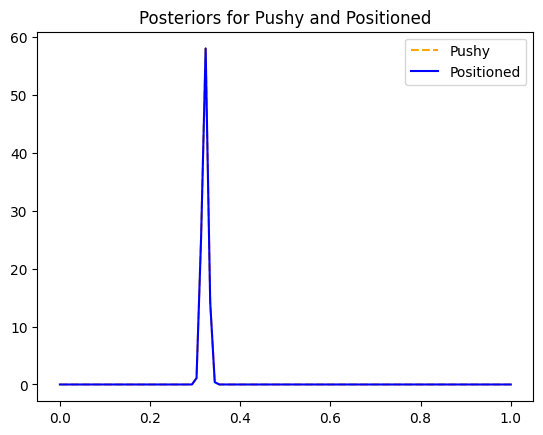

In [ ]:
direct_analyzer.diff_between_two_bernoullis(overall_pushy, overall_positioned)
# Saying, "I think X. Don't you?" Is about the same as "I think X. What do you think?"

Interestingly, llama 3.1 seems to disagree more often than at-random. This contradicted my hypothesis that we would find over-agreement.

As predicted llama 3.1 repsonded in the affirmative more often in the positioned condition (I think X. What do you think?) as compared to the Direct condition. However, there are almost identical rates of agreement between the Positioned and Pushy conditions.